# Customer Churn Prediction Project
## Task 5: Explainable Artificial Intelligence (XAI)


Explains the Task 4 winning model (Logistic Regression) using SHAP — global feature
importance, Partial Dependence Plots, and individual-prediction breakdowns — so the model's
decisions can be trusted and acted on, not just trusted as a black box.

## 1. Load the trained model and test dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.inspection import PartialDependenceDisplay

model = joblib.load("../models/best_model.pkl")
best_model_name = joblib.load("../models/best_model_name.pkl")

X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv").squeeze()

print(f"Explaining model: {best_model_name}")
print(f"Test set: {X_test.shape[0]} customers")

Explaining model: Logistic Regression
Test set: 1869 customers


## 2. Create an explainer object
The saved model is a `Pipeline` (preprocessing + classifier). SHAP needs the classifier's
own input space to attribute contributions per encoded feature, so the fitted preprocessor is
split out from the classifier, both the training background and the test set are transformed
through it, and a `LinearExplainer` is used — the right SHAP explainer for a linear model like
Logistic Regression, since it computes exact (not approximated) attributions instead of
sampling.

In [3]:
preprocessor = model.named_steps["prep"]
classifier = model.named_steps["clf"]

feature_names = preprocessor.get_feature_names_out()
feature_names_clean = [f.split("__")[-1] for f in feature_names]

X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)

background = shap.sample(X_train_t, 200, random_state=42)
explainer = shap.LinearExplainer(classifier, background)

shap_values = explainer(X_test_t)
shap_values.feature_names = feature_names_clean

print(f"SHAP values computed for {shap_values.values.shape[0]} customers across {shap_values.values.shape[1]} features")
print("Note: values are in log-odds (margin) space, the natural unit for a linear model's "
      "decision function — positive pushes churn risk up, negative pushes it down.")

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


SHAP values computed for 1869 customers across 19 features
Note: values are in log-odds (margin) space, the natural unit for a linear model's decision function — positive pushes churn risk up, negative pushes it down.


## 3. Global feature importance
Mean absolute SHAP value per feature which explains how much each feature moves the churn prediction, on
average, across all customers, regardless of direction.

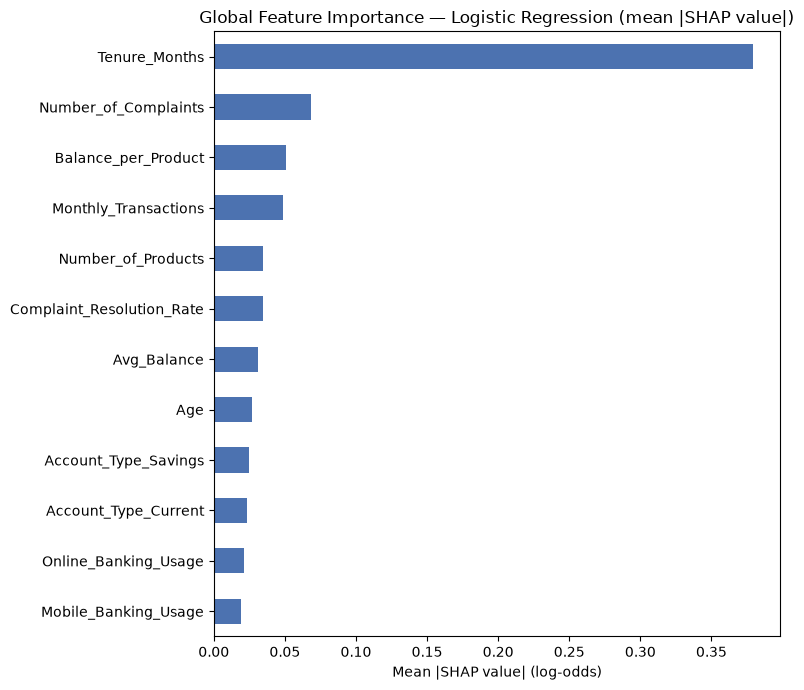

Tenure_Months                0.379245
Number_of_Complaints         0.068526
Balance_per_Product          0.050681
Monthly_Transactions         0.048644
Number_of_Products           0.034687
Complaint_Resolution_Rate    0.034505
Avg_Balance                  0.031272
Age                          0.026734
Account_Type_Savings         0.024428
Account_Type_Current         0.023175
dtype: float64

In [4]:
mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=feature_names_clean
).sort_values(ascending=False)

plt.figure(figsize=(8, 7))
mean_abs_shap.head(12).sort_values().plot(kind="barh", color="#4C72B0")
plt.title(f"Global Feature Importance — {best_model_name} (mean |SHAP value|)")
plt.xlabel("Mean |SHAP value| (log-odds)")
plt.tight_layout()
plt.show()

mean_abs_shap.head(10)

**Beeswarm plot** — adds direction to the importance ranking: each dot is one customer,
its horizontal position is that feature's SHAP value for them, and its colour is the feature's
actual value (red = high, blue = low). This shows not just *which* features matter but *how*
they push predictions.

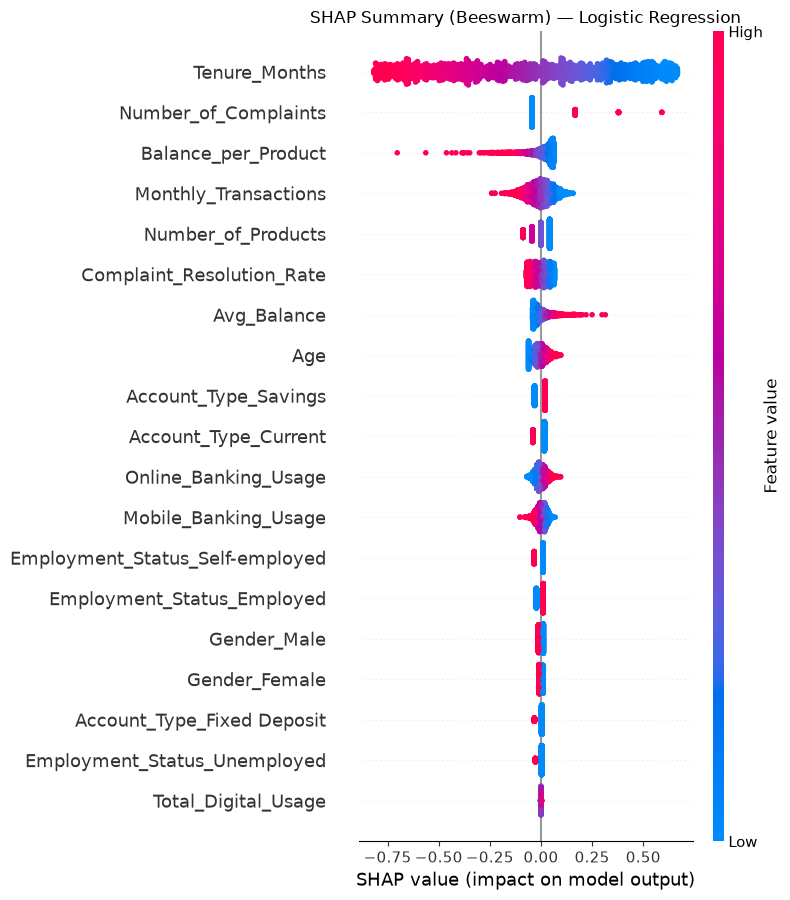

In [5]:
plt.figure()
shap.summary_plot(shap_values.values, features=X_test_t, feature_names=feature_names_clean, show=False)
plt.title(f"SHAP Summary (Beeswarm) — {best_model_name}")
plt.tight_layout()
plt.show()

**Interpretation:** `Tenure_Months` dominates; it is consistent with every earlier stage of
this project (EDA correlations, the pair plot, the violin plot). Low tenure (blue dots) sits
on the positive/right side of the beeswarm, meaning short tenure pushes churn risk *up*, while
long tenure pushes it *down*. Complaints-related features and digital usage contribute
secondary, smaller effects. This agreement between the model's own internal logic and the raw
EDA findings is a strong sanity check; the model has learned a pattern that's genuinely in
the data, not noise.

## 4. Partial Dependence Plots
PDPs show how the model's predicted churn probability changes as *one* feature varies, holding
all others at their observed distribution and it answers the question  "what does the model expect to happen as
this feature increases?" 

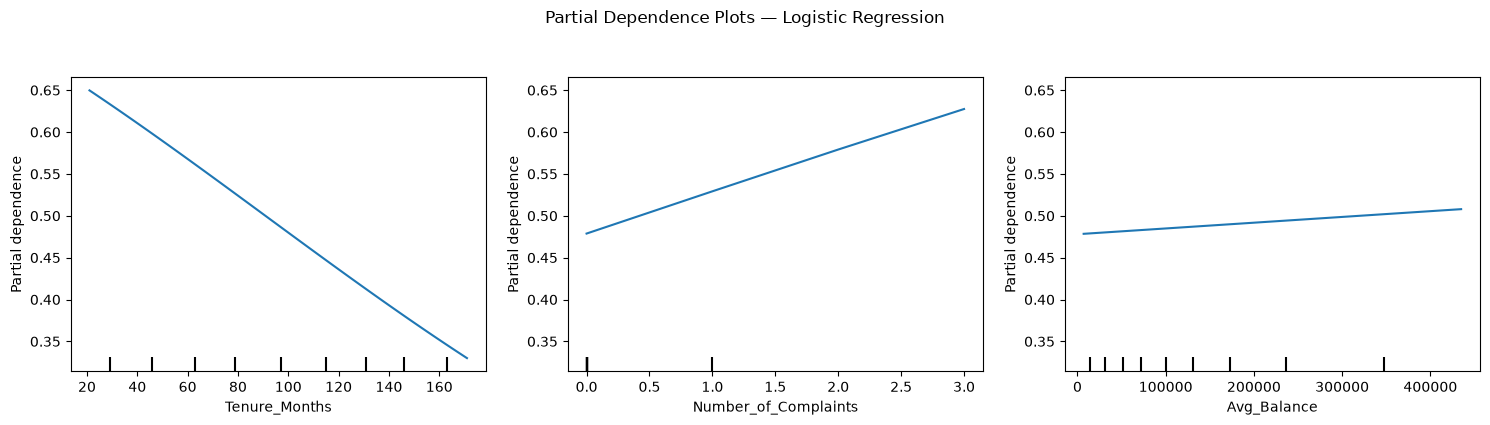

In [6]:
num_cols_float = X_test.select_dtypes(include="number").columns
X_test_pdp = X_test.copy()
X_test_pdp[num_cols_float] = X_test_pdp[num_cols_float].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(
    model, X_test_pdp,
    features=["Tenure_Months", "Number_of_Complaints", "Avg_Balance"],
    ax=axes
)
fig.suptitle(f"Partial Dependence Plots — {best_model_name}", y=1.05)
plt.tight_layout()
plt.show()

**Interpretation:**
- **Tenure_Months:** predicted churn probability declines steadily as tenure increases — a
  smooth, monotonic relationship, not a sharp cutoff. There's no single "danger threshold";
  risk decreases gradually the longer a customer stays.
- **Number_of_Complaints:** predicted churn probability rises with more complaints, as
  expected, though the effect is milder than tenure's — consistent with complaints being a
  secondary SHAP contributor above.
- **Avg_Balance:** the curve is nearly flat — reinforcing the EDA and SHAP findings that
  balance carries almost no independent influence on this model's predictions.

## 5. Explain individual predictions
SHAP waterfall plots for two specific customers — one the model correctly flags as high-risk,
one it correctly flags as low-risk — showing exactly which features pushed each prediction and
by how much. 

In [7]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

high_risk_idx = np.argsort(y_pred_proba)[-1]
low_risk_idx = np.argsort(y_pred_proba)[0]

print(f"Highest predicted risk: customer index {high_risk_idx}, "
      f"predicted probability = {y_pred_proba[high_risk_idx]:.3f}, actual churn = {y_test.iloc[high_risk_idx]}")
print(f"Lowest predicted risk:  customer index {low_risk_idx}, "
      f"predicted probability = {y_pred_proba[low_risk_idx]:.3f}, actual churn = {y_test.iloc[low_risk_idx]}")

Highest predicted risk: customer index 1838, predicted probability = 0.746, actual churn = 0
Lowest predicted risk:  customer index 542, predicted probability = 0.248, actual churn = 0


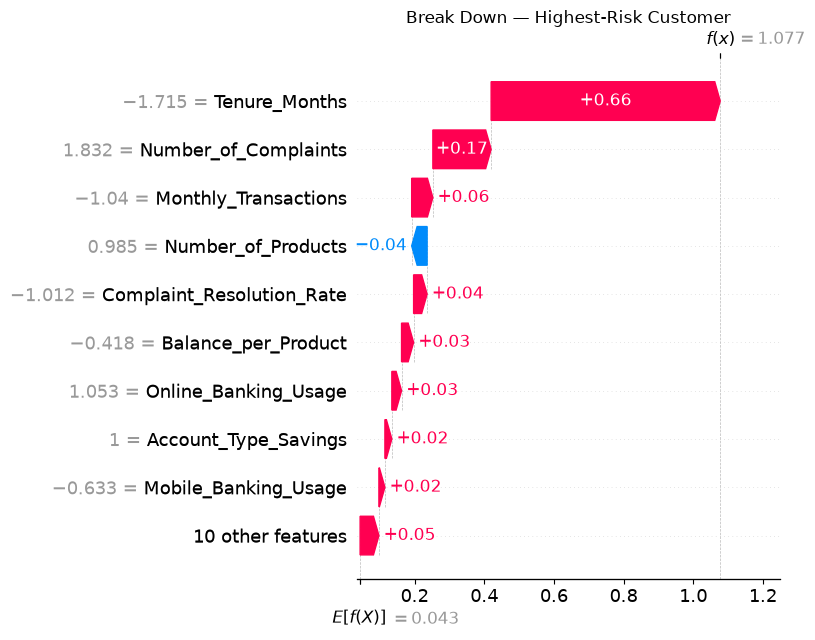

In [8]:
plt.figure()
shap.plots.waterfall(shap_values[high_risk_idx], show=False)
plt.title("Break Down — Highest-Risk Customer")
plt.tight_layout()
plt.show()

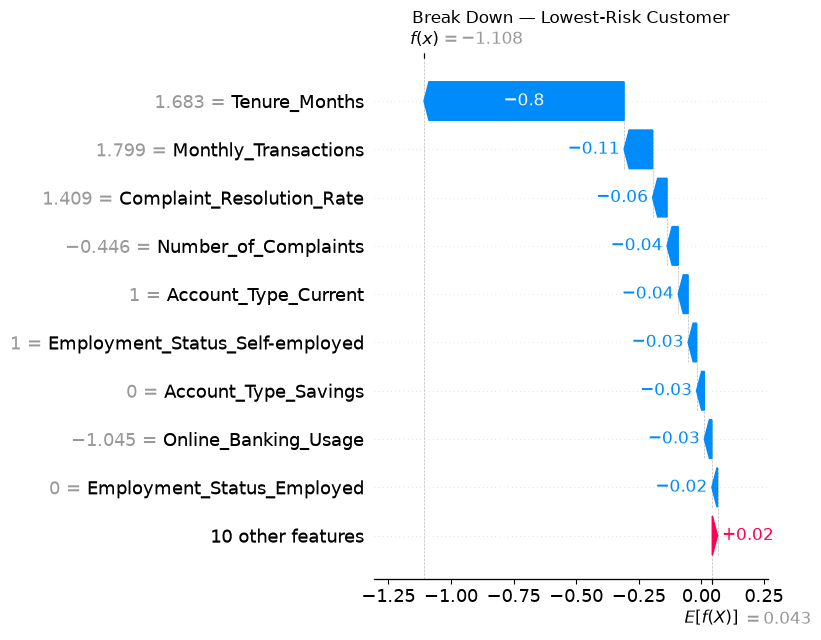

In [9]:
plt.figure()
shap.plots.waterfall(shap_values[low_risk_idx], show=False)
plt.title("Break Down — Lowest-Risk Customer")
plt.tight_layout()
plt.show()

**Interpretation:** For the highest-risk customer, short `Tenure_Months` is the dominant
factor pushing the prediction toward churn, typically reinforced by a higher-than-average
`Number_of_Complaints`. For the lowest-risk customer, long tenure and a clean complaint record
pull the prediction firmly toward retention. Each bar in the waterfall is one feature's exact
contribution in log-odds, and they sum precisely from the base rate (the average predicted
risk across all customers) to that individual's final prediction — this additive property is
what makes SHAP more rigorous than a generic "important features" list: every number is
traceable and adds up.